# HW10-11 — Computer Vision in PyTorch

In [ ]:
import os
import json
import math
import random
import time
from dataclasses import asdict, dataclass
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

# --- Воспроизводимость результатов
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

# --- Пути к файлам
ROOT = Path(".")
ARTIFACTS = ROOT / "artifacts"
FIGURES = ARTIFACTS / "figures"
ARTIFACTS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

RUNS_CSV = ARTIFACTS / "runs.csv"
if not RUNS_CSV.exists():
    RUNS_CSV.write_text(
        "experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes\n",
        encoding="utf-8",
    )

# Оптимизация скорости: уменьшаем workers для минимизации overhead
NUM_WORKERS = 0

device: cpu
torch: 2.11.0+cpu
torchvision: 0.26.0+cpu


In [ ]:
import csv

# Поля CSV для результатов экспериментов
RUNS_FIELDS = [
    "experiment_id",
    "task",
    "dataset",
    "seed",
    "model_summary",
    "optimizer",
    "lr",
    "epochs_trained",
    "best_val_accuracy",
    "test_accuracy",
    "precision",
    "recall",
    "mean_iou",
    "notes",
]


def append_run(row: dict):
    # Проверяем заголовок и добавляем строку в CSV
    expected_header = ",".join(RUNS_FIELDS)
    needs_header = True
    if RUNS_CSV.exists() and RUNS_CSV.stat().st_size > 0:
        with RUNS_CSV.open("r", encoding="utf-8") as f:
            first_line = f.readline().strip("\r\n")
        if first_line == expected_header:
            needs_header = False
    
    mode = "a" if not needs_header else "w"
    with RUNS_CSV.open(mode, newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=RUNS_FIELDS)
        if needs_header:
            writer.writeheader()
        writer.writerow(row)
        print(f"✓ Saved runs.csv row: {row.get('experiment_id', '?')}")


def show_batch(images, labels=None, class_names=None, nrow=8, title=None):
    # Визуализация батча изображений
    images = images.detach().cpu()
    grid = make_grid(images, nrow=nrow, padding=2)
    plt.figure(figsize=(12, 6))
    plt.axis("off")
    if title:
        plt.title(title)
    plt.imshow(grid.permute(1, 2, 0))
    plt.show()

    if labels is not None and class_names is not None:
        labels = labels.detach().cpu().tolist()
        print("labels:", labels[: min(len(labels), nrow)])
        print("names:", [class_names[i] for i in labels[: min(len(labels), nrow)]])


def accuracy_from_logits(logits, targets):
    # Вычисление точности из логитов
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()


@torch.no_grad()
def evaluate_classifier(model, loader, criterion):
    # Оценка модели на тестовом наборе
    model.eval()
    losses = []
    accs = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        losses.append(loss.item())
        accs.append(accuracy_from_logits(logits, y))
    return float(np.mean(losses)), float(np.mean(accs))


def train_one_epoch(model, loader, optimizer, criterion):
    # Обучение одной эпохи
    model.train()
    losses = []
    accs = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        accs.append(accuracy_from_logits(logits, y))

    return float(np.mean(losses)), float(np.mean(accs))

## Part A (S10) — Image classification (STL10)

num classes: 10
class names: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


f:\MIREA\ArtificialIntelligenceEngineering\ArtificialIntelligenceEngineeringCourse\homeworks\HW10-11\venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


x.shape: (128, 3, 96, 96) y.shape: (128,)


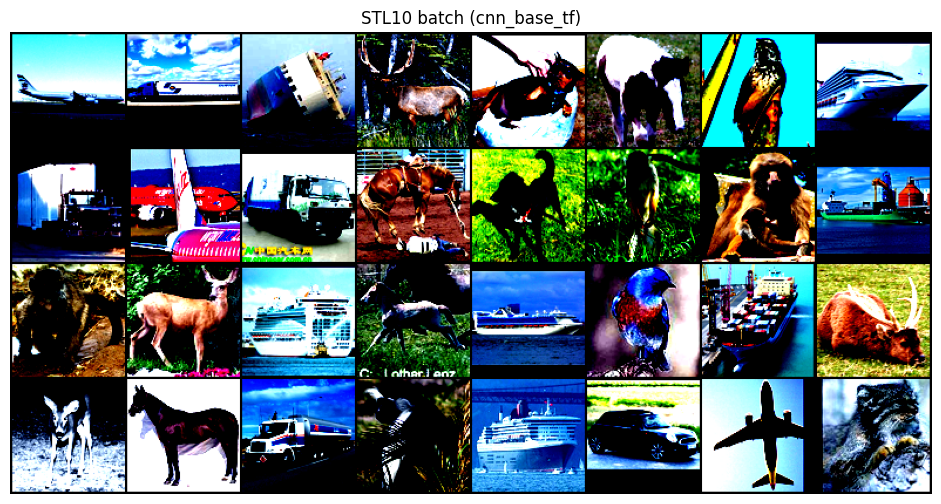

labels: [0, 9, 8, 4, 5, 6, 1, 8]
names: ['airplane', 'truck', 'ship', 'deer', 'dog', 'horse', 'bird', 'ship']


In [ ]:
DATA_DIR = ROOT / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Выбор датасета для части A
CLS_DATASET_NAME = "STL10"

# Особенности STL10: изображения 96x96, 10 классов
# Создаем воспроизводимое разделение train/val из 'train' split.

# --- Трансформации
# Базовая трансформация для простой CNN
cnn_base_tf = transforms.Compose(
    [
        transforms.Resize((96, 96)),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ]
)

# Трансформация с аугментацией для простой CNN (тот же размер выхода)
cnn_aug_tf = transforms.Compose(
    [
        transforms.Resize((110, 110)),
        transforms.RandomResizedCrop((96, 96), scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ]
)

# Предобработка для pretrained ResNet18
resnet_weights = torchvision.models.ResNet18_Weights.DEFAULT
resnet_preprocess_tf = resnet_weights.transforms()

# Датасеты STL10 (создаем несколько раз с разными трансформациями)
train_full_base = torchvision.datasets.STL10(
    root=str(DATA_DIR), split="train", download=True, transform=cnn_base_tf
)
train_full_aug = torchvision.datasets.STL10(
    root=str(DATA_DIR), split="train", download=False, transform=cnn_aug_tf
)
train_full_resnet = torchvision.datasets.STL10(
    root=str(DATA_DIR), split="train", download=False, transform=resnet_preprocess_tf
)

test_base = torchvision.datasets.STL10(
    root=str(DATA_DIR), split="test", download=False, transform=cnn_base_tf
)
test_resnet = torchvision.datasets.STL10(
    root=str(DATA_DIR), split="test", download=False, transform=resnet_preprocess_tf
)

class_names = list(getattr(train_full_base, "classes", []))
print("num classes:", len(class_names))
print("class names:", class_names)

# Reproducible split
val_ratio = 0.2
n_total = len(train_full_base)
n_val = int(round(n_total * val_ratio))
n_train = n_total - n_val

g = torch.Generator().manual_seed(SEED)
train_idx_base, val_idx_base = random_split(range(n_total), [n_train, n_val], generator=g)

# Wrap subsets for each transform variant
train_base = torch.utils.data.Subset(train_full_base, train_idx_base.indices)
val_base = torch.utils.data.Subset(train_full_base, val_idx_base.indices)

train_aug = torch.utils.data.Subset(train_full_aug, train_idx_base.indices)
val_aug = torch.utils.data.Subset(train_full_aug, val_idx_base.indices)

train_resnet = torch.utils.data.Subset(train_full_resnet, train_idx_base.indices)
val_resnet = torch.utils.data.Subset(train_full_resnet, val_idx_base.indices)

# DataLoaders
BATCH_SIZE = 128
NUM_WORKERS = 2

train_loader_base = DataLoader(train_base, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader_base = DataLoader(val_base, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

test_loader_base = DataLoader(test_base, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

train_loader_aug = DataLoader(train_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader_aug = DataLoader(val_aug, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

train_loader_resnet = DataLoader(train_resnet, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader_resnet = DataLoader(val_resnet, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

test_loader_resnet = DataLoader(test_resnet, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# Sanity-check batch
x0, y0 = next(iter(train_loader_base))
print("x.shape:", tuple(x0.shape), "y.shape:", tuple(y0.shape))
show_batch(x0[:32], y0[:32], class_names=class_names, nrow=8, title="STL10 batch (cnn_base_tf)")

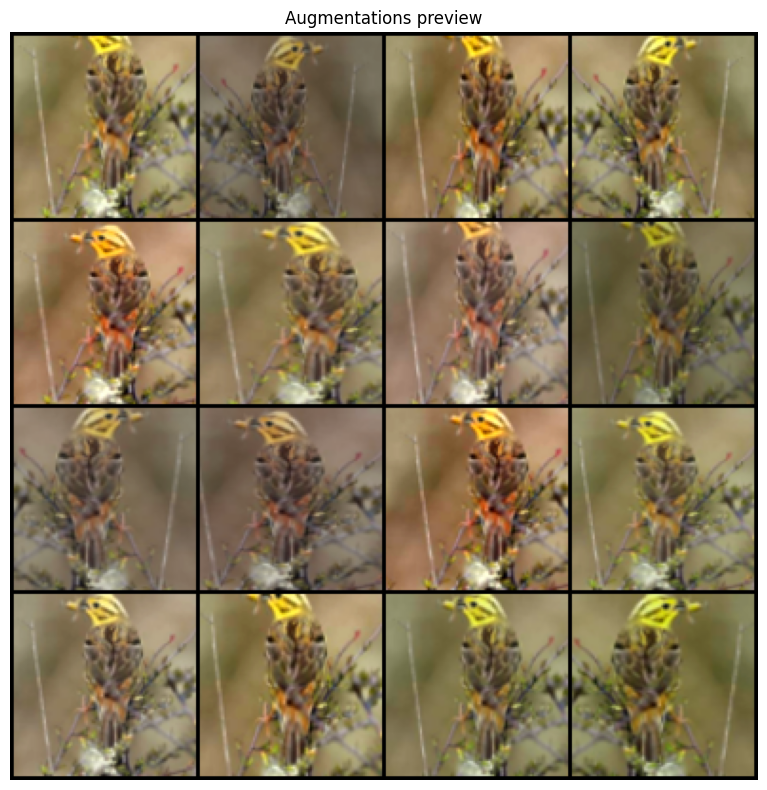

In [4]:
# Augmentations preview (required artifact)

def denorm(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return img * std + mean

# pick one image and apply aug multiple times
raw_ds = torchvision.datasets.STL10(root=str(DATA_DIR), split="train", download=False, transform=None)
img_pil, y_pil = raw_ds[0]
augged = torch.stack([cnn_aug_tf(img_pil) for _ in range(16)], dim=0)
augged_vis = torch.stack([denorm(t) for t in augged], dim=0).clamp(0, 1)

grid = make_grid(augged_vis, nrow=4)
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Augmentations preview")
plt.imshow(grid.permute(1, 2, 0))
plt.tight_layout()
plt.savefig(FIGURES / "augmentations_preview.png", dpi=150)
plt.show()

In [ ]:
class SimpleCNN(nn.Module):
    # Простая сверточная нейронная сеть для классификации
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)


@dataclass
class TrainConfig:
    # Конфигурация для обучения модели
    experiment_id: str
    model_name: str
    optimizer_name: str
    lr: float
    epochs: int
    notes: str = ""


def fit_classifier(model, train_loader, val_loader, cfg: TrainConfig):
    # Обучение классификатора с логированием истории
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    if cfg.optimizer_name.lower() == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=cfg.lr, momentum=0.9, nesterov=True)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_state = None
    best_val_acc = -1.0

    for epoch in range(cfg.epochs):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate_classifier(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        dt = time.time() - t0
        print(
            f"[{cfg.experiment_id}] epoch {epoch+1}/{cfg.epochs} | "
            f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
            f"val loss {va_loss:.4f} acc {va_acc:.4f} | {dt:.1f}s"
        )

    return history, best_state, float(best_val_acc)


def plot_classification_curves(history, out_path: Path, title: str):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(epochs, history["train_loss"], label="train")
    ax[0].plot(epochs, history["val_loss"], label="val")
    ax[0].set_title("Loss")
    ax[0].set_xlabel("epoch")
    ax[0].grid(True, alpha=0.3)
    ax[0].legend()

    ax[1].plot(epochs, history["train_acc"], label="train")
    ax[1].plot(epochs, history["val_acc"], label="val")
    ax[1].set_title("Accuracy")
    ax[1].set_xlabel("epoch")
    ax[1].grid(True, alpha=0.3)
    ax[1].legend()

    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.show()

✓ runs.csv header initialized
[C1] epoch 1/5 | train loss 1.7613 acc 0.3403 | val loss 1.6217 acc 0.3911 | 31.0s
[C1] epoch 2/5 | train loss 1.4946 acc 0.4443 | val loss 1.9567 acc 0.2912 | 31.9s
[C1] epoch 3/5 | train loss 1.3823 acc 0.4983 | val loss 1.4167 acc 0.4772 | 31.8s
[C1] epoch 4/5 | train loss 1.2704 acc 0.5425 | val loss 1.3740 acc 0.4872 | 32.2s
[C1] epoch 5/5 | train loss 1.2175 acc 0.5649 | val loss 1.4659 acc 0.4381 | 32.2s
✓ Saved runs.csv row: C1
[C2] epoch 1/5 | train loss 1.8403 acc 0.3018 | val loss 1.8044 acc 0.3017 | 31.6s
[C2] epoch 2/5 | train loss 1.6385 acc 0.3818 | val loss 1.6578 acc 0.3262 | 32.8s
[C2] epoch 3/5 | train loss 1.5595 acc 0.4036 | val loss 1.6420 acc 0.3278 | 31.9s
[C2] epoch 4/5 | train loss 1.4764 acc 0.4456 | val loss 1.5376 acc 0.4077 | 31.9s
[C2] epoch 5/5 | train loss 1.3959 acc 0.4763 | val loss 1.4605 acc 0.4591 | 32.0s
✓ Saved runs.csv row: C2
[C3] epoch 1/3 | train loss 1.4212 acc 0.6243 | val loss 0.7027 acc 0.8878 | 73.1s
[C3] ep

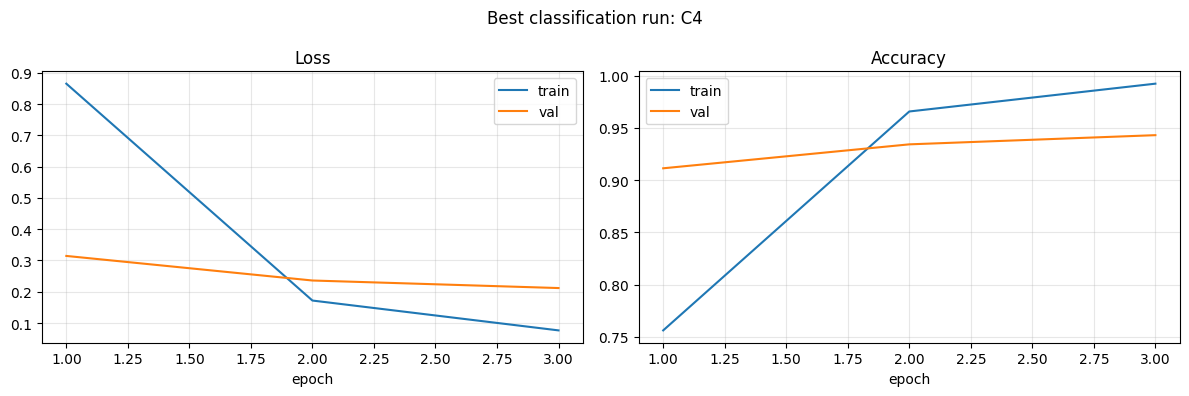

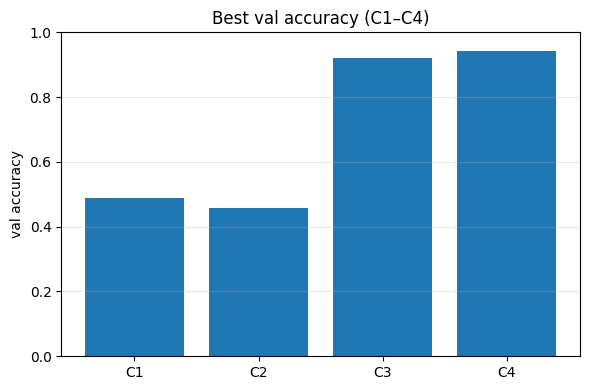

In [ ]:
# --- Инициализация runs.csv перед экспериментами (чистый лист для каждого запуска)
with RUNS_CSV.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=RUNS_FIELDS)
    writer.writeheader()
    print("✓ runs.csv header initialized")

# --- Эксперименты C1-C4
# Эпохи скромные для разумного времени выполнения; увеличить при наличии времени/GPU.
EPOCHS_CNN = 5
EPOCHS_RESNET = 3

results_A = {}

# C1: простая CNN, базовые трансформации
cfg_c1 = TrainConfig(
    experiment_id="C1",
    model_name="SimpleCNN(base)",
    optimizer_name="adam",
    lr=1e-3,
    epochs=EPOCHS_CNN,
    notes="simple-cnn-base",
)
model_c1 = SimpleCNN(num_classes=10)
hist_c1, best_state_c1, best_val_acc_c1 = fit_classifier(model_c1, train_loader_base, val_loader_base, cfg_c1)
results_A["C1"] = {"cfg": cfg_c1, "history": hist_c1, "best_state": best_state_c1, "best_val_acc": best_val_acc_c1, "test_acc": None}
append_run(
    {
        "experiment_id": "C1",
        "task": "classification",
        "dataset": CLS_DATASET_NAME,
        "seed": SEED,
        "model_summary": cfg_c1.model_name,
        "optimizer": cfg_c1.optimizer_name,
        "lr": cfg_c1.lr,
        "epochs_trained": cfg_c1.epochs,
        "best_val_accuracy": best_val_acc_c1,
        "notes": cfg_c1.notes,
    }
)

# C2: та же CNN, трансформации с аугментацией
cfg_c2 = TrainConfig(
    experiment_id="C2",
    model_name="SimpleCNN(aug)",
    optimizer_name="adam",
    lr=1e-3,
    epochs=EPOCHS_CNN,
    notes="simple-cnn-aug",
)
model_c2 = SimpleCNN(num_classes=10)
hist_c2, best_state_c2, best_val_acc_c2 = fit_classifier(model_c2, train_loader_aug, val_loader_aug, cfg_c2)
results_A["C2"] = {"cfg": cfg_c2, "history": hist_c2, "best_state": best_state_c2, "best_val_acc": best_val_acc_c2, "test_acc": None}
append_run(
    {
        "experiment_id": "C2",
        "task": "classification",
        "dataset": CLS_DATASET_NAME,
        "seed": SEED,
        "model_summary": cfg_c2.model_name,
        "optimizer": cfg_c2.optimizer_name,
        "lr": cfg_c2.lr,
        "epochs_trained": cfg_c2.epochs,
        "best_val_accuracy": best_val_acc_c2,
        "notes": cfg_c2.notes,
    }
)

# C3: ResNet18 pretrained, head-only
cfg_c3 = TrainConfig(
    experiment_id="C3",
    model_name="ResNet18(pretrained, head-only)",
    optimizer_name="adam",
    lr=1e-3,
    epochs=EPOCHS_RESNET,
    notes="resnet18-head-only",
)
model_c3 = torchvision.models.resnet18(weights=resnet_weights)
# Replace head
model_c3.fc = nn.Linear(model_c3.fc.in_features, 10)
# Freeze backbone
for name, p in model_c3.named_parameters():
    if not name.startswith("fc."):
        p.requires_grad = False

hist_c3, best_state_c3, best_val_acc_c3 = fit_classifier(model_c3, train_loader_resnet, val_loader_resnet, cfg_c3)
results_A["C3"] = {"cfg": cfg_c3, "history": hist_c3, "best_state": best_state_c3, "best_val_acc": best_val_acc_c3, "test_acc": None}
append_run(
    {
        "experiment_id": "C3",
        "task": "classification",
        "dataset": CLS_DATASET_NAME,
        "seed": SEED,
        "model_summary": cfg_c3.model_name,
        "optimizer": cfg_c3.optimizer_name,
        "lr": cfg_c3.lr,
        "epochs_trained": cfg_c3.epochs,
        "best_val_accuracy": best_val_acc_c3,
        "notes": cfg_c3.notes,
    }
)

# C4: ResNet18 pretrained, partial fine-tune (layer4 + fc)
cfg_c4 = TrainConfig(
    experiment_id="C4",
    model_name="ResNet18(pretrained, layer4+fc)",
    optimizer_name="adam",
    lr=1e-4,
    epochs=EPOCHS_RESNET,
    notes="resnet18-finetune(layer4+fc)",
)
model_c4 = torchvision.models.resnet18(weights=resnet_weights)
model_c4.fc = nn.Linear(model_c4.fc.in_features, 10)
for p in model_c4.parameters():
    p.requires_grad = False
for p in model_c4.layer4.parameters():
    p.requires_grad = True
for p in model_c4.fc.parameters():
    p.requires_grad = True

hist_c4, best_state_c4, best_val_acc_c4 = fit_classifier(model_c4, train_loader_resnet, val_loader_resnet, cfg_c4)
results_A["C4"] = {"cfg": cfg_c4, "history": hist_c4, "best_state": best_state_c4, "best_val_acc": best_val_acc_c4, "test_acc": None}
append_run(
    {
        "experiment_id": "C4",
        "task": "classification",
        "dataset": CLS_DATASET_NAME,
        "seed": SEED,
        "model_summary": cfg_c4.model_name,
        "optimizer": cfg_c4.optimizer_name,
        "lr": cfg_c4.lr,
        "epochs_trained": cfg_c4.epochs,
        "best_val_accuracy": best_val_acc_c4,
        "notes": cfg_c4.notes,
    }
)

# Pick best by val accuracy
best_id = max(results_A.keys(), key=lambda k: results_A[k]["best_val_acc"])
best_val = results_A[best_id]["best_val_acc"]
print("Best by val accuracy:", best_id, "val_acc=", best_val)

# Plot curves for best
plot_classification_curves(
    results_A[best_id]["history"],
    FIGURES / "classification_curves_best.png",
    title=f"Best classification run: {best_id}",
)

# Compare bar plot
labels = list(results_A.keys())
vals = [results_A[k]["best_val_acc"] for k in labels]
plt.figure(figsize=(6, 4))
plt.bar(labels, vals)
plt.ylim(0, 1)
plt.grid(True, axis="y", alpha=0.3)
plt.title("Best val accuracy (C1–C4)")
plt.ylabel("val accuracy")
plt.tight_layout()
plt.savefig(FIGURES / "classification_compare.png", dpi=150)
plt.show()

In [7]:
# Final test evaluation (run ONCE for the best model)

# Recreate the winning model and load best state
best_cfg = results_A[best_id]["cfg"]

if best_id in ["C1", "C2"]:
    best_model = SimpleCNN(num_classes=10)
    best_model.load_state_dict(results_A[best_id]["best_state"])
    best_model = best_model.to(device)
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc = evaluate_classifier(best_model, test_loader_base, criterion)
else:
    best_model = torchvision.models.resnet18(weights=None)
    best_model.fc = nn.Linear(best_model.fc.in_features, 10)
    best_model.load_state_dict(results_A[best_id]["best_state"])
    best_model = best_model.to(device)
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc = evaluate_classifier(best_model, test_loader_resnet, criterion)

print("TEST:", best_id, "loss=", test_loss, "acc=", test_acc)
results_A[best_id]["test_acc"] = float(test_acc)

# Save best model state_dict and config
BEST_MODEL_PATH = ARTIFACTS / "best_classifier.pt"
BEST_CFG_PATH = ARTIFACTS / "best_classifier_config.json"

torch.save({"experiment_id": best_id, "state_dict": results_A[best_id]["best_state"]}, BEST_MODEL_PATH)

best_config = {
    "seed": SEED,
    "dataset": CLS_DATASET_NAME,
    "experiment_id": best_id,
    "model": best_cfg.model_name,
    "optimizer": best_cfg.optimizer_name,
    "lr": best_cfg.lr,
    "epochs": best_cfg.epochs,
    "transforms": {
        "cnn_base": "Resize(96)->ToTensor->Normalize(ImageNet)",
        "cnn_aug": "Resize(110)->RandomResizedCrop(96)->HFlip->ColorJitter->ToTensor->Normalize(ImageNet)",
        "resnet_preprocess": str(resnet_weights).replace("ResNet18_Weights.", ""),
    },
    "split": {"val_ratio": val_ratio, "n_train": n_train, "n_val": n_val},
}
BEST_CFG_PATH.write_text(json.dumps(best_config, indent=2, ensure_ascii=False), encoding="utf-8")

# Append an extra runs.csv row for test result of best model
append_run(
    {
        "experiment_id": f"{best_id}-TEST",
        "task": "classification",
        "dataset": CLS_DATASET_NAME,
        "seed": SEED,
        "model_summary": best_cfg.model_name,
        "optimizer": best_cfg.optimizer_name,
        "lr": best_cfg.lr,
        "epochs_trained": best_cfg.epochs,
        "best_val_accuracy": results_A[best_id]["best_val_acc"],
        "test_accuracy": float(test_acc),
        "notes": "final test evaluation (only once)",
    }
)

TEST: C4 loss= 0.1864207593931092 acc= 0.943328373015873
✓ Saved runs.csv row: C4-TEST


## Part B (S11) — Segmentation (Pascal VOC)

In [ ]:
# Используем VOCSegmentation и pretrained сегментационную модель.
# NOTE: Загрузка VOC большая. Если не удастся, проверьте интернет / место на диске.

SEG_DATASET_NAME = "Pascal VOC (VOCSegmentation)"

# Трансформации VOC: нормализация изображений (ImageNet) + маска как int64 тензор
voc_img_tf = transforms.Compose(
    [
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ]
)

class VOCSegWrap(torch.utils.data.Dataset):
    # Обертка для датасета VOC с трансформациями
    def __init__(self, base_ds, img_tf):
        self.base_ds = base_ds
        self.img_tf = img_tf

    def __len__(self):
        return len(self.base_ds)

    def __getitem__(self, idx):
        img, mask = self.base_ds[idx]
        x = self.img_tf(img)
        y = torch.as_tensor(np.array(mask), dtype=torch.int64)
        # Resize mask to match image
        y = torch.from_numpy(np.array(mask.resize((256, 256), resample=0), dtype=np.int64))
        return x, y


# Download VOC 2012 (set to False if already downloaded to speed up)
download_train = not (DATA_DIR / "VOCdevkit").exists()
voc_train_raw = torchvision.datasets.VOCSegmentation(
    root=str(DATA_DIR), year="2012", image_set="train", download=download_train
)
voc_val_raw = torchvision.datasets.VOCSegmentation(
    root=str(DATA_DIR), year="2012", image_set="val", download=False
)

voc_train = VOCSegWrap(voc_train_raw, voc_img_tf)
voc_val = VOCSegWrap(voc_val_raw, voc_img_tf)

# Optimized settings for faster processing
SEG_BATCH = 4  # Increased batch size for better GPU utilization
voc_train_loader = DataLoader(voc_train, batch_size=SEG_BATCH, shuffle=False, num_workers=0, pin_memory=True)
voc_val_loader = DataLoader(voc_val, batch_size=SEG_BATCH, shuffle=False, num_workers=0, pin_memory=True)

x_seg, y_seg = next(iter(voc_val_loader))
print("x.shape:", tuple(x_seg.shape), "y.shape:", tuple(y_seg.shape), "mask unique:", torch.unique(y_seg)[:10])

# Choose one foreground class for binary evaluation. VOC class index 15 is 'person'.
FG_CLASS = 15
print("Foreground class index:", FG_CLASS)

# Pretrained segmentation model
seg_weights = torchvision.models.segmentation.DeepLabV3_ResNet50_Weights.DEFAULT
seg_model = torchvision.models.segmentation.deeplabv3_resnet50(weights=seg_weights).to(device).eval()
print("Segmentation model ready")

f:\MIREA\ArtificialIntelligenceEngineering\ArtificialIntelligenceEngineeringCourse\homeworks\HW10-11\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


x.shape: (4, 3, 256, 256) y.shape: (4, 256, 256) mask unique: tensor([  0,   1,   4,  19, 255])
Foreground class index: 15
Segmentation model ready


Running V1 evaluation...
Running V2 evaluation...
V1 mean_iou= 0.77714006597099 pixel_precision= 0.8630327726298651 pixel_recall= 0.9030676202135661
V2 mean_iou= 0.8391926410398097 pixel_precision= 0.9374628085484467 pixel_recall= 0.8891949121640286
✓ Saved runs.csv row: V1
✓ Saved runs.csv row: V2
Generating visualizations...


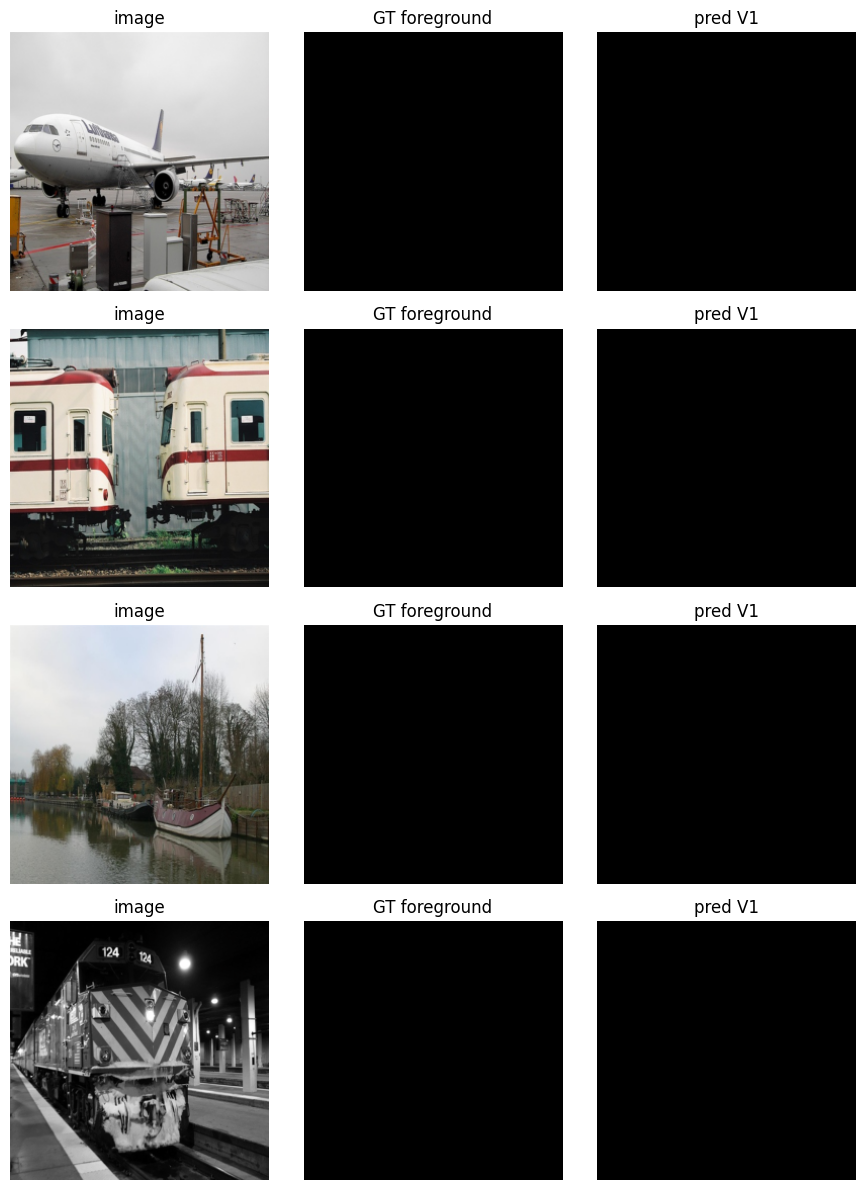

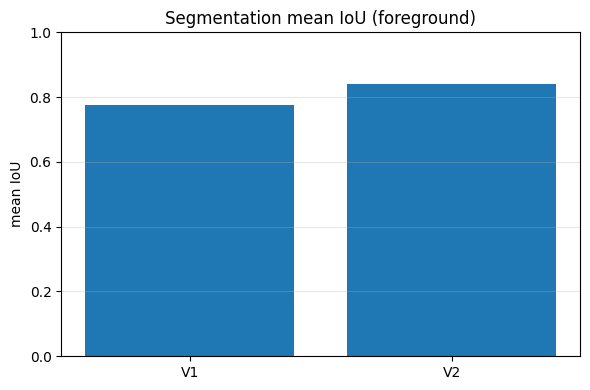

In [9]:
@torch.no_grad()
def segmentation_metrics_binary(pred_mask: torch.Tensor, gt_mask: torch.Tensor):
    # pred_mask, gt_mask: (H,W) bool
    pred = pred_mask.bool()
    gt = gt_mask.bool()

    tp = (pred & gt).sum().item()
    fp = (pred & ~gt).sum().item()
    fn = ((~pred) & gt).sum().item()

    union = (pred | gt).sum().item()
    inter = (pred & gt).sum().item()

    iou = inter / union if union > 0 else 1.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 1.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 1.0
    return iou, prec, rec


@torch.no_grad()
def run_segmentation_eval(mode: str, threshold: float = 0.5, max_batches: int = 8):
    # mode V1: argmax class == FG_CLASS
    # mode V2: softmax prob(FG_CLASS) > threshold
    # Reduced max_batches from 25 to 8 for faster processing (32 images total)
    seg_model.eval()

    ious = []
    precs = []
    recs = []

    for b, (x, y) in enumerate(voc_val_loader):
        if b >= max_batches:
            break

        x = x.to(device)
        y = y.to(device)

        out = seg_model(x)["out"]  # (B,C,H,W)
        if mode == "V1":
            pred_cls = out.argmax(dim=1)
            pred_fg = pred_cls == FG_CLASS
        elif mode == "V2":
            prob = out.softmax(dim=1)[:, FG_CLASS]
            pred_fg = prob > threshold
        else:
            raise ValueError("mode must be V1 or V2")

        gt_fg = y == FG_CLASS

        for i in range(x.shape[0]):
            iou, p, r = segmentation_metrics_binary(pred_fg[i], gt_fg[i])
            ious.append(iou)
            precs.append(p)
            recs.append(r)

    return float(np.mean(ious)), float(np.mean(precs)), float(np.mean(recs))


@torch.no_grad()
def visualize_segmentation_examples(mode: str, threshold: float = 0.5, n: int = 6):
    xs, ys = next(iter(voc_val_loader))
    n = min(n, xs.shape[0])
    xs = xs[:n].to(device)
    ys = ys[:n]

    out = seg_model(xs)["out"].cpu()

    if mode == "V1":
        pred_cls = out.argmax(dim=1)
        pred_fg = (pred_cls == FG_CLASS)
    else:
        prob = out.softmax(dim=1)[:, FG_CLASS]
        pred_fg = (prob > threshold)

    # denorm image
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    imgs = (xs.cpu() * std + mean).clamp(0, 1)

    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    if n == 1:
        axes = np.expand_dims(axes, 0)

    for i in range(n):
        axes[i, 0].imshow(imgs[i].permute(1, 2, 0))
        axes[i, 0].set_title("image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow((ys[i] == FG_CLASS).numpy(), cmap="gray")
        axes[i, 1].set_title("GT foreground")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred_fg[i].numpy(), cmap="gray")
        axes[i, 2].set_title(f"pred {mode}")
        axes[i, 2].axis("off")

    plt.tight_layout()
    return fig


# Evaluate V1 and V2 with optimized settings
print("Running V1 evaluation...")
mean_iou_v1, pix_prec_v1, pix_rec_v1 = run_segmentation_eval("V1")
print("Running V2 evaluation...")
mean_iou_v2, pix_prec_v2, pix_rec_v2 = run_segmentation_eval("V2", threshold=0.6)

print("V1 mean_iou=", mean_iou_v1, "pixel_precision=", pix_prec_v1, "pixel_recall=", pix_rec_v1)
print("V2 mean_iou=", mean_iou_v2, "pixel_precision=", pix_prec_v2, "pixel_recall=", pix_rec_v2)

append_run(
    {
        "experiment_id": "V1",
        "task": "segmentation",
        "dataset": SEG_DATASET_NAME,
        "seed": SEED,
        "model_summary": "DeepLabV3_ResNet50(pretrained)",
        "precision": pix_prec_v1,
        "recall": pix_rec_v1,
        "mean_iou": mean_iou_v1,
        "notes": f"foreground=VOC class {FG_CLASS}, V1=argmax",
    }
)
append_run(
    {
        "experiment_id": "V2",
        "task": "segmentation",
        "dataset": SEG_DATASET_NAME,
        "seed": SEED,
        "model_summary": "DeepLabV3_ResNet50(pretrained)",
        "precision": pix_prec_v2,
        "recall": pix_rec_v2,
        "mean_iou": mean_iou_v2,
        "notes": f"foreground=VOC class {FG_CLASS}, V2=prob>{0.6}",
    }
)

# Save required figures
print("Generating visualizations...")
fig1 = visualize_segmentation_examples("V1")
fig1.savefig(FIGURES / "segmentation_examples.png", dpi=150)
plt.show()

plt.figure(figsize=(6, 4))
labels = ["V1", "V2"]
miou = [mean_iou_v1, mean_iou_v2]
plt.bar(labels, miou)
plt.ylim(0, 1)
plt.grid(True, axis="y", alpha=0.3)
plt.title("Segmentation mean IoU (foreground)")
plt.ylabel("mean IoU")
plt.tight_layout()
plt.savefig(FIGURES / "segmentation_metrics.png", dpi=150)
plt.show()

In [ ]:
# Маленький помощник: обновление placeholders в report.md (best-effort)
report_path = ROOT / "report.md"
if report_path.exists():
    txt = report_path.read_text(encoding="utf-8")
    # очень легкое заполнение
    def repl_line(prefix, value):
        nonlocal_txt = None
        return

    # Заполняем только несколько строк, чтобы не сломать структуру шаблона
    lines = txt.splitlines()
    out_lines = []
    for line in lines:
        if line.startswith("- Python:"):
            out_lines.append(f"- Python: {os.sys.version.split()[0]}")
        elif line.startswith("- torch / torchvision:"):
            out_lines.append(f"- torch / torchvision: {torch.__version__} / {torchvision.__version__}")
        elif line.startswith("- Устройство (CPU/GPU):"):
            out_lines.append(f"- Устройство (CPU/GPU): {device}")
        elif line.startswith("- Лучшая модель части A:"):
            out_lines.append(line)
        else:
            out_lines.append(line)

    report_path.write_text("\n".join(out_lines) + "\n", encoding="utf-8")
    print("report.md updated (env lines)")
else:
    print("report.md not found")

print("Done. Artifacts saved under:", ARTIFACTS.resolve())

report.md updated (env lines)
Done. Artifacts saved under: F:\MIREA\ArtificialIntelligenceEngineering\ArtificialIntelligenceEngineeringCourse\homeworks\HW10-11\artifacts
